### Regresión con Variables Categóricas e Interacción

En informática médica, a menudo evaluamos cómo un tratamiento interactúa con condiciones biológicas. Utilizaremos el dataset ToothGrowth, que mide la longitud de los odontoblastos (len) en cobayos tras recibir vitamina C a través de dos métodos: jugo de naranja (OJ) o ácido ascórbico (VC), en diferentes dosis.

### 3.1 Análisis Exploratorio (EDA)

Aquí el enfoque cambia hacia la comparación de grupos.

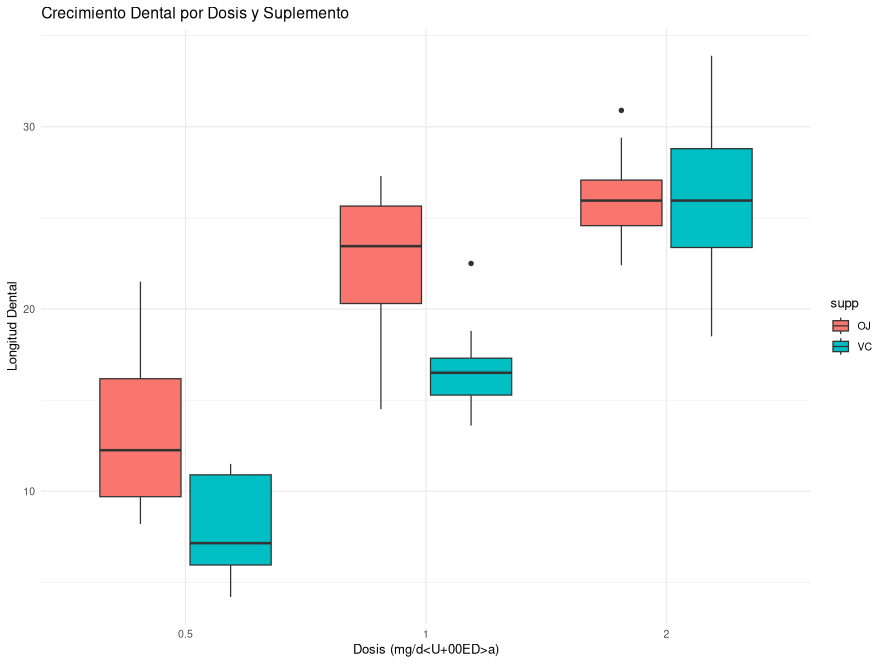

In [11]:
data("ToothGrowth")

# Visualización del efecto del método de entrega
library(ggplot2)
ggplot(ToothGrowth, aes(x=as.factor(dose), y=len, fill=supp)) +
  geom_boxplot() +
  labs(title="Crecimiento Dental por Dosis y Suplemento",
       x="Dosis (mg/día)", y="Longitud Dental") +
  theme_minimal()

In [12]:
# Summary statistics by dose and supplement
aggregate(len ~ dose + supp, data = ToothGrowth, FUN = mean)

  dose supp   len
1  0.5   OJ 13.23
2  1.0   OJ 22.70
3  2.0   OJ 26.06
4  0.5   VC  7.98
5  1.0   VC 16.77
6  2.0   VC 26.14

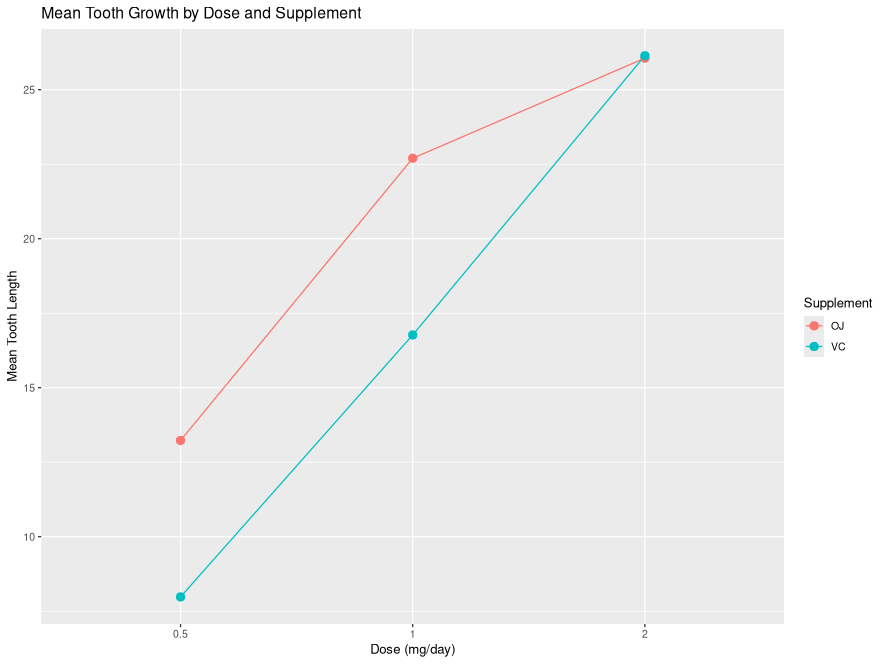

In [13]:
# Visualize mean tooth growth by dose and supplement type
ggplot(aggregate(len ~ dose + supp, data = ToothGrowth, FUN = mean), 
       aes(x = as.factor(dose), y = len, color = supp, group = supp)) +
  geom_line() +
  geom_point(size = 3) +
  labs(title = "Mean Tooth Growth by Dose and Supplement",
       x = "Dose (mg/day)",
       y = "Mean Tooth Length",
       color = "Supplement")

In [14]:
# Two-way ANOVA to test effects of dose and supplement on tooth growth
summary(aov(len ~ as.factor(dose) + supp + as.factor(dose):supp, data = ToothGrowth))

                     Df Sum Sq Mean Sq F value   Pr(>F)    
as.factor(dose)       2 2426.4  1213.2  92.000  < 2e-16 ***
supp                  1  205.3   205.3  15.572 0.000231 ***
as.factor(dose):supp  2  108.3    54.2   4.107 0.021860 *  
Residuals            54  712.1    13.2                     
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

### Modelamiento con Interacción
Es posible que el efecto de la dosis dependa del método de entrega. Esto se modela mediante un término de interacción:

$$Y = \beta_0 + \beta_1 Dosis + \beta_2 Supp_{VC} + \beta_3 (Dosis \times Supp_{VC}) + \epsilon$$

In [15]:
modelo_3 <- lm(len ~ dose * supp, data = ToothGrowth)
summary(modelo_3)


Call:
lm(formula = len ~ dose * supp, data = ToothGrowth)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.2264 -2.8462  0.0504  2.2893  7.9386 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   11.550      1.581   7.304 1.09e-09 ***
dose           7.811      1.195   6.534 2.03e-08 ***
suppVC        -8.255      2.236  -3.691 0.000507 ***
dose:suppVC    3.904      1.691   2.309 0.024631 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4.083 on 56 degrees of freedom
Multiple R-squared:  0.7296,	Adjusted R-squared:  0.7151 
F-statistic: 50.36 on 3 and 56 DF,  p-value: 6.521e-16


El término dose:suppVC evalúa si la pendiente de la dosis cambia significativamente entre los dos métodos de suplementación. Si el valor p es < 0.05, confirmamos que el método de administración modifica el efecto de la dosis sobre el crecimiento dental.